<h1>Backpropagation and Gradient Flow</h1>
<h3>Chain rule, Computational Graphs, Gradient Flow, Cross-Entropy, Softmax</h3>

<h3>Softmax & Cross-Entropy</h3>

The code cell below contain 2 functions, the softmax and corss_entropy functions. Softmax takes as an argument an array of neural network outputs, and return the same inputs as probabilities. The probailities are always between 0 and 1. Cross_entropy takes 2 parameters: the probabilities returned by the softmax function predictions and the truth labels labels. The truth lables indicate which is the target class. The cross_etropy function returns the loss calculated, which is how close or far the probability is to the correct class.

In [52]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def softmax(x):
  exps = np.exp(x - np.max(x))
  return exps / np.sum(exps)

def cross_entropy(predictions, labels):
  return -np.sum(labels * np.log(predictions + 1e-15))

In [3]:
logits = np.array([3.0, 1.0, 0.1])
true_label = np.array([1, 0, 0])

prob = softmax(logits)
print("Softmax probabilities:", prob)
print("Sum of probabilities: ", np.sum(prob))

loss = cross_entropy(prob, true_label)
print("Cross-entropy loss:", loss)

Softmax probabilities: [0.84008305 0.11369288 0.04622407]
Sum of probabilities:  1.0
Cross-entropy loss: 0.17425452502421487


<h3>Understanding the Chain Rule through Code</h3>

The Chain Rule is the engine of backpropagation. In calculus, it allows us to compute the derivative of a composite function. In code, it allows us to propagate 'blame' for the final error back through every single variable in our system. If we have a function $z = f(g(x))$, the change in $z$ with respect to $x$ is:

$$\frac{dz}{dx} = \frac{dz}{dy} \times \frac{dy}{dx}$$

In [5]:
class Value:
    """ 
    A data structure that stores a scalar value and its gradient, 
    maintaining the computational graph.
    """
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0  # Initially, the gradient is 0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), '*')

    def __repr__(self):
        return f"Value(label={self.label}, data={self.data}, grad={self.grad})"

<h3>The Forward Pass</h3>

We will define a simple expression: $d = (a \times b) + c$.

In this scenario: 
1. $e = a \times b$ 
2. $d = e + c$

By calculating the forward pass, we build a Computational Graph.

In [6]:
# Initialize our inputs
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

# Forward pass
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'

print(f"Output value (d): {d.data}")

Output value (d): 4.0


<h3>The Backward Pass</h3>

To find out how each input affects the output $d$, we apply the chain rule in reverse.

1. The Base Case: $\frac{dd}{dd} = 1.0$ (The derivative of the output with respect to itself).
2. The Addition Rule: Since $d = e + c$, the local derivatives $\frac{dd}{de}$ and $\frac{dd}{dc}$ are both $1.0$.
3. The Multiplication Rule: Since $e = a \times b$, the local derivative $\frac{de}{da} = b$ and $\frac{de}{db} = a$.

In [7]:
# 1. Seed the gradient of the final output
d.grad = 1.0

# 2. Backpropagate through the '+' node (d = e + c)
# Gradient is distributed 1-to-1
e.grad = 1.0 * d.grad
c.grad = 1.0 * d.grad

# 3. Backpropagate through the '*' node (e = a * b)
# Gradient is the 'other' value multiplied by the incoming gradient
a.grad = b.data * e.grad
b.grad = a.data * e.grad

print(f"Gradient of a (dd/da): {a.grad}")
print(f"Gradient of b (dd/db): {b.grad}")
print(f"Gradient of c (dd/dc): {c.grad}")

Gradient of a (dd/da): -3.0
Gradient of b (dd/db): 2.0
Gradient of c (dd/dc): 1.0


By decomposing complex functions into simple operations such as addition and multiplication, we can apply the chain rule locally at every step. This modularity is exactly how libraries like PyTorch and TensorFlow handle billions of parameters, they just repeat this simple logic over and over again.

<h3>Gradient Descent</h3>

Gradient Descent is the backbone of modern machine learning. At its core, it’s an optimization algorithm used to minimize a function by iteratively moving in the direction of steepest descent.

In the code cell above, the function gradient_descent is designed to find the optimal parameters for a linear regression model. It takes four arguments: the input features x, the target values y, a learning_rate to control the step size, and the number of iterations to run the optimization.

In [ ]:
def functional_gradient_descent(start_x, learning_rate=0.1, iterations=10):
    f = lambda x: x**2
    df = lambda x: 2 * x
    
    x_curr = start_x
    history = []
    
    for i in range(iterations):
        # Record: (current x, current y, current slope)
        history.append((x_curr, f(x_curr), df(x_curr)))
        
        # Gradient Descent Step
        grad = df(x_curr)
        x_curr = x_curr - (learning_rate * grad)
        
    return history, f

From the below code cell, the learning rate and the iterations can be modified to experiment and visually see the affect learning rate and the number of iterations has on the optimisation of the weights.

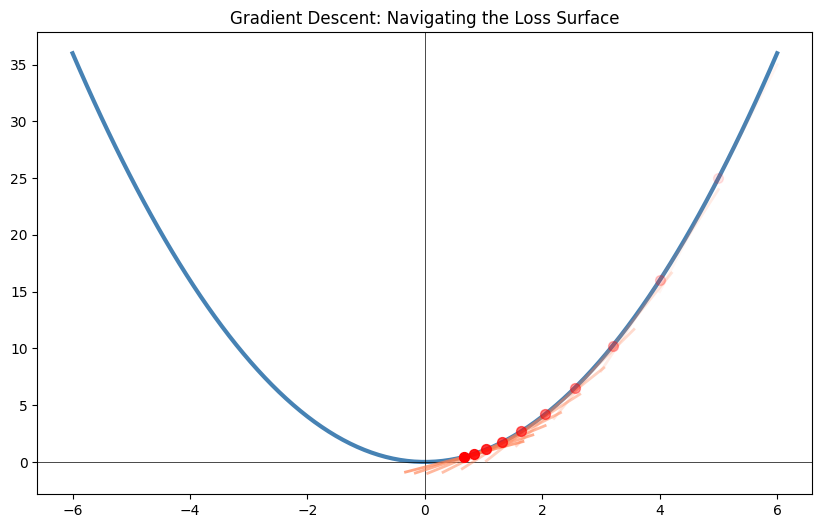

In [ ]:
history, f = functional_gradient_descent(start_x=5, learning_rate=0.1, iterations=10)

fig, ax = plt.subplots(figsize=(10, 6))

x_range = np.linspace(-6, 6, 100)
ax.plot(x_range, f(x_range), color="steelblue", lw=3, zorder=1)

for i, (x_val, y_val, slope) in enumerate(history):
    alpha = (i + 1) / len(history)
    
    ax.scatter(x_val, y_val, color="red", s=50, alpha=alpha, zorder=5)
    
    tan_x = np.linspace(x_val - 1, x_val + 1, 10)
    tan_y = slope * (tan_x - x_val) + y_val
    ax.plot(tan_x, tan_y, color="coral", alpha=alpha * 0.7, lw=2, zorder=4)
    

ax.set_title("Gradient Descent: Navigating the Loss Surface")
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
plt.show()

In [ ]:
def initialize_nn():
    return {
        # Weights: He Initialization sqrt(2/fan_in)
        'W1': np.random.randn(3, 2) * np.sqrt(2 / 2),
        'W2': np.random.randn(2, 3) * np.sqrt(2 / 3),
        
        # Biases: Explicitly zero
        'b1': np.zeros((3, 1)),
        'b2': np.zeros((2, 1)),
        
        # Momentum Velocities: Must be zero
        'vW1': np.zeros((3, 2)),
        'vb1': np.zeros((3, 1)),
        'vW2': np.zeros((2, 3)),
        'vb2': np.zeros((2, 1)),
        'a1': np.zeros((3, 1)),
        'a2': np.zeros((2, 1)),
        'step': "Ready",
        'loss_history': [],
    }
    

<h3>Some Helper Function to help NN visualisation</h3>

In [ ]:
nn = initialize_nn()

target_idx = 1
y_target = np.zeros((2, 1))
y_target[target_idx] = 1.0

def train_step(nn, x_in, y_target, target_idx, lr=0.01):
    
    #Forward Pass
    nn['z1'] = np.dot(nn['W1'], x_in) + nn['b1']
    nn['a1'] = np.maximum(0, nn['z1']) 
    nn['z2'] = np.dot(nn['W2'], nn['a1']) + nn['b2']
    shift_z2 = nn['z2'] - np.max(nn['z2'])
    nn['a2'] = np.exp(shift_z2) / np.sum(np.exp(shift_z2), axis=0)
    
    #Backward Pass
    dz2 = nn['a2'] - y_target
    nn['dW2'] = np.dot(dz2, nn['a1'].T)
    nn['db2'] = dz2
    dz1 = np.dot(nn['W2'].T, dz2) * (nn['z1'] > 0).astype(float)
    nn['dW1'] = np.dot(dz1, x_in.T)
    nn['db1'] = dz1
    
    #Update Weights
    beta = 0.9
    nn['vW1'] = beta * nn['vW1'] + (1 - beta) * nn['dW1']
    nn['vb1'] = beta * nn['vb1'] + (1 - beta) * nn['db1']
    nn['W1'] -= lr * nn['vW1']
    nn['b1'] -= lr * nn['vb1']
    
    nn['vW2'] = beta * nn['vW2'] + (1 - beta) * nn['dW2']
    nn['vb2'] = beta * nn['vb2'] + (1 - beta) * nn['db2']
    nn['W2'] -= lr * nn['vW2']
    nn['b2'] -= lr * nn['vb2']
    
    #Record Loss
    loss = -np.log(nn['a2'][target_idx, 0] + 1e-9)
    nn['loss_history'].append(loss)
    nn['step'] = "Full Iteration Complete"

def draw_network():
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    ax.set_aspect('equal')
    ax.axis('off')

    cols = {'in': -5, 'hid': 0, 'out': 5}
    y_coords = {'in': [1.5, -1.5], 'hid': [2.5, 0, -2.5], 'out': [1.5, -1.5]}

    #Weights & Connections
    for i, yi in enumerate(y_coords['in']):
        for j, yj in enumerate(y_coords['hid']):
            ax.plot([cols['in'], cols['hid']], [yi, yj], color='gray', lw=1, alpha=0.3, zorder=1)
            t, stagger = 0.3, (0.2 if i == 0 else -0.2)
            ax.text(cols['in'] + (cols['hid']-cols['in'])*t, yi + (yj-yi)*t + stagger, 
                    f"{nn['W1'][j,i]:.2f}", color='blue', fontsize=9, ha='center',
                    fontweight='bold', zorder=5, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))

    for i, yi in enumerate(y_coords['hid']):
        for j, yj in enumerate(y_coords['out']):
            ax.plot([cols['hid'], cols['out']], [yi, yj], color='gray', lw=1, alpha=0.3, zorder=1)
            t, stagger = 0.7, ([0.25, 0, -0.25][i])
            ax.text(cols['hid'] + (cols['out']-cols['hid'])*t, yi + (yj-yi)*t + stagger, 
                    f"{nn['W2'][j,i]:.2f}", color='blue', fontsize=9, ha='center',
                    fontweight='bold', zorder=5, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))

    #Input Nodes
    for i, y in enumerate(y_coords['in']):
        ax.add_patch(patches.Circle((cols['in'], y), 0.75, fc='white', ec='black', lw=2, zorder=10))
        ax.text(cols['in'], y, f"{x_in[i,0]:.2f}", 
                ha='center', va='center', color='black', fontweight='bold', fontsize=11, zorder=20)

    #Hidden Nodes
    for i, y in enumerate(y_coords['hid']):
        val = nn.get('a1', np.zeros((3,1)))[i,0]
        node_color = '#6a0dad' if val > 0 else '#4169e1' # Purple if active, Blue if inactive
        
        ax.add_patch(patches.Circle((cols['hid'], y), 0.75, fc=node_color, ec='black', lw=2, zorder=10))
        ax.text(cols['hid'], y, f"{val:.2f}", 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11, zorder=20)

    # Output Nodes
    for i, y in enumerate(y_coords['out']):
        prob_val = nn.get('a2', np.zeros((2,1)))[i, 0]
        edge_c = 'red' if i == target_idx else 'black'
        
        ax.add_patch(patches.Circle((cols['out'], y), 0.75, fc='white', ec=edge_c, lw=3, zorder=10))
        ax.text(cols['out'], y, f"P({i})\n{prob_val:.4f}", 
                ha='center', va='center', color='black', fontweight='bold', fontsize=11, zorder=20)

    plt.show()

Running the below code cell will generate a number of graphs, these graphs will show how the input parameters and the randomly generated weights affect the final output. Each iteration is an full training step of the Neural Network, startking from the forward pass and ending with the updates of the weights. The Next iteration will pass throught the training step again and show the new graph with the updated weights and the probabilites.

 ITERATION 1 | Loss: 1.3622


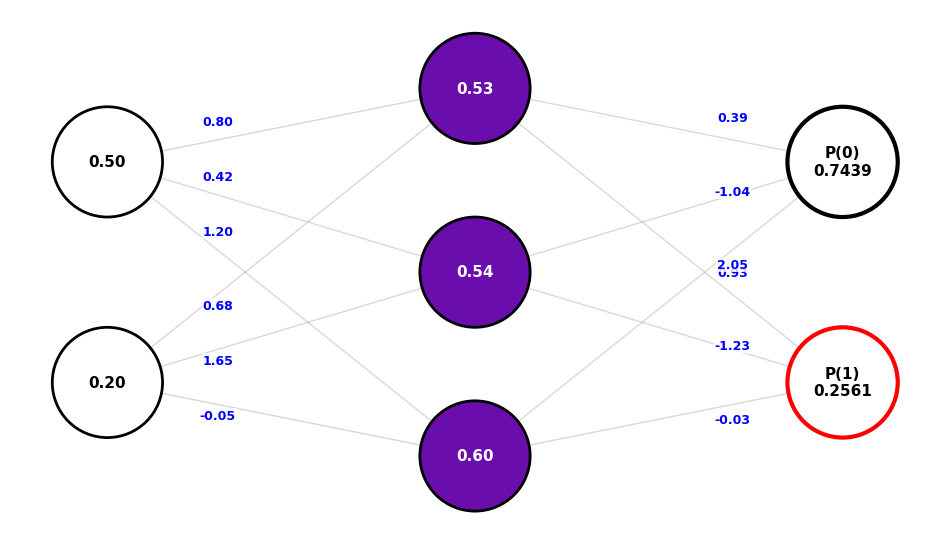

 ITERATION 2 | Loss: 1.3082


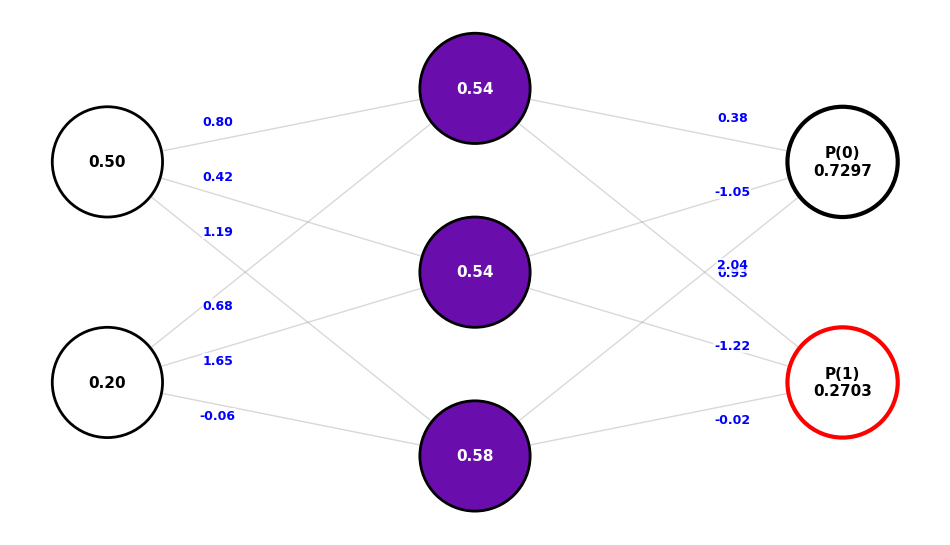

 ITERATION 3 | Loss: 1.2102


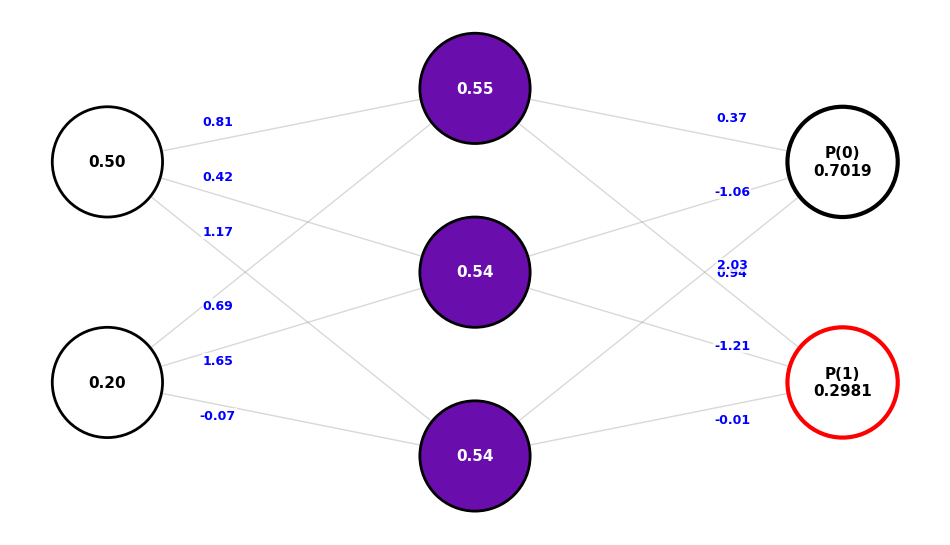

 ITERATION 4 | Loss: 1.0810


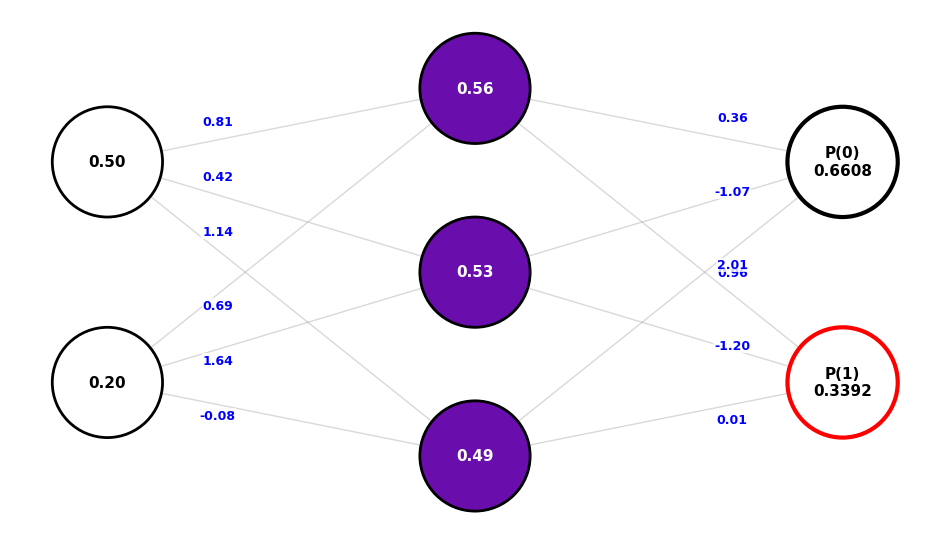

 ITERATION 5 | Loss: 0.9346


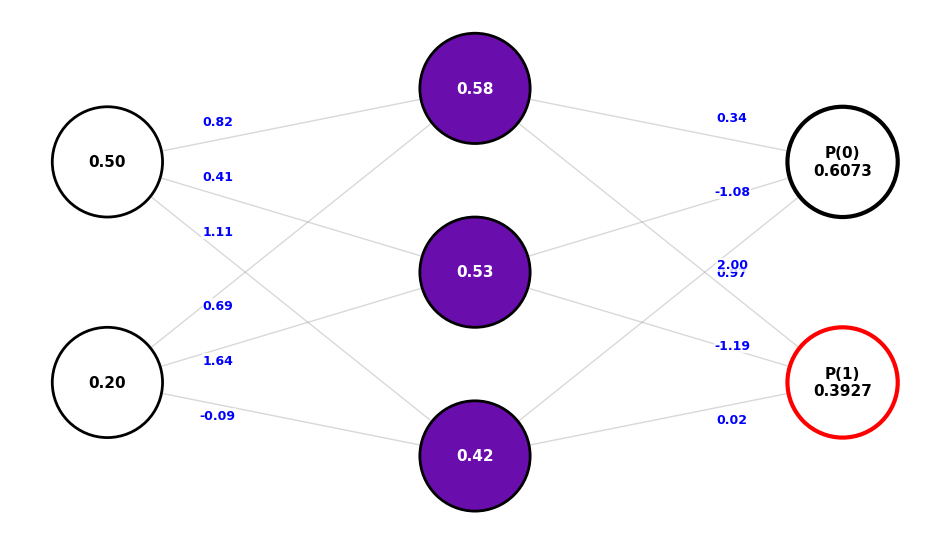

 ITERATION 6 | Loss: 0.7843


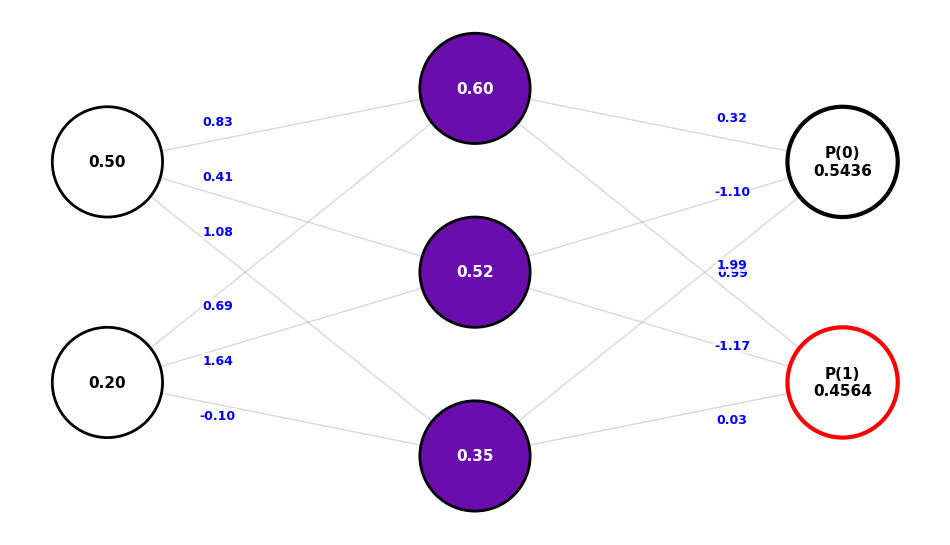

 ITERATION 7 | Loss: 0.6413


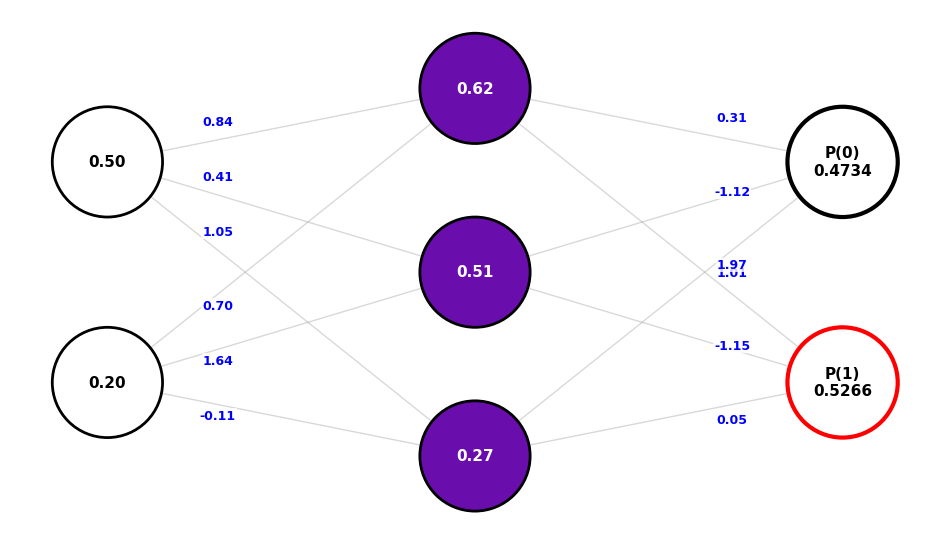

 ITERATION 8 | Loss: 0.5137


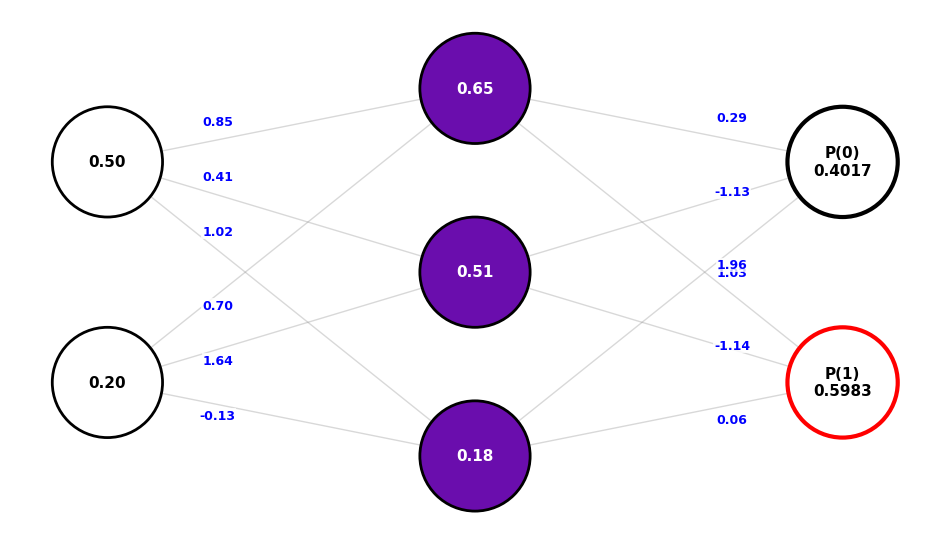

 ITERATION 9 | Loss: 0.4055


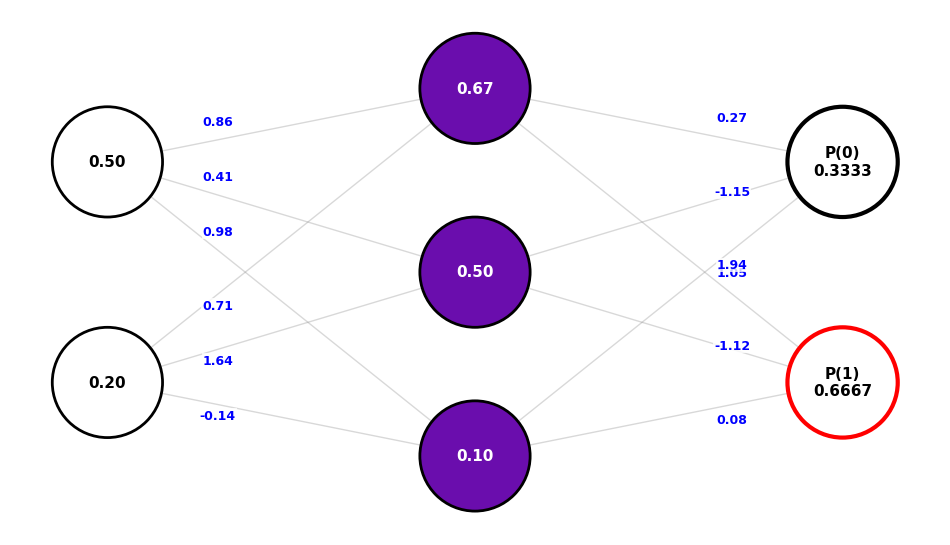

 ITERATION 10 | Loss: 0.3173


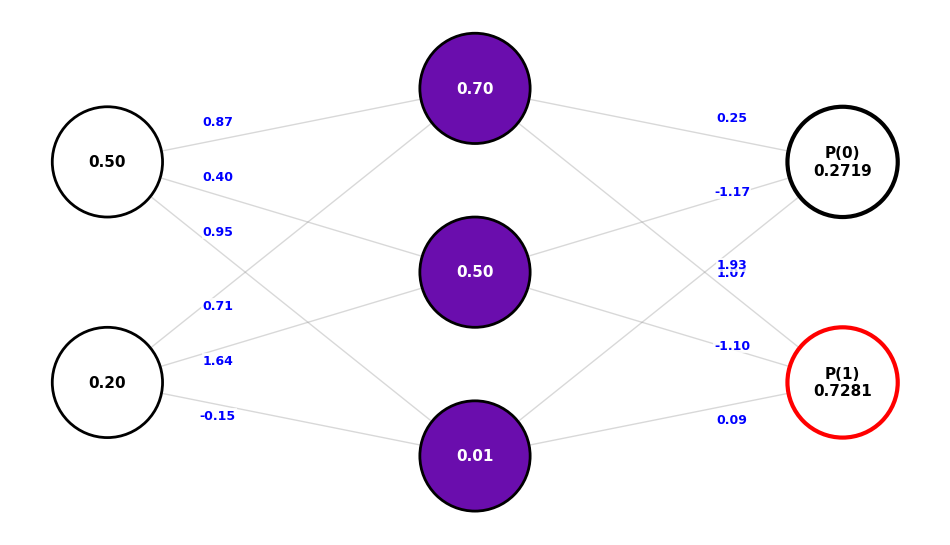

 ITERATION 11 | Loss: 0.2781


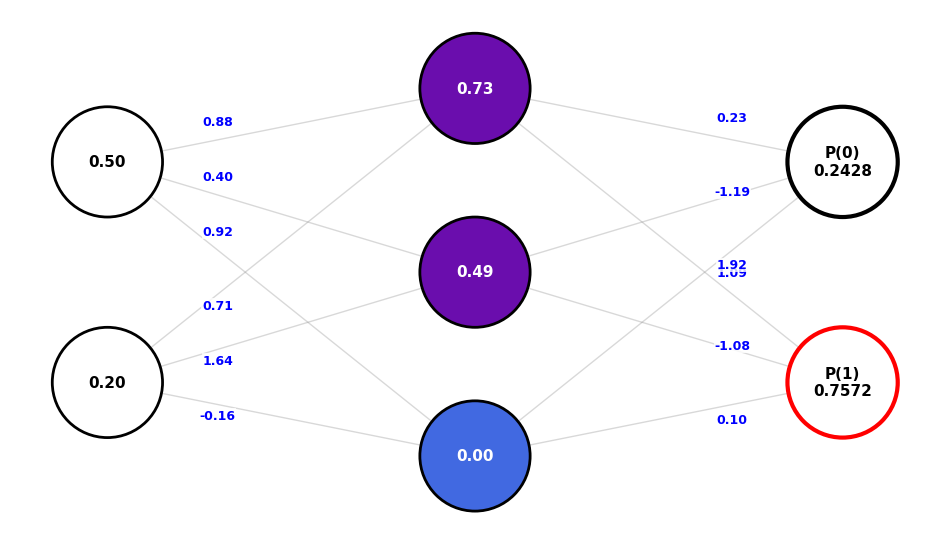

 ITERATION 12 | Loss: 0.2482


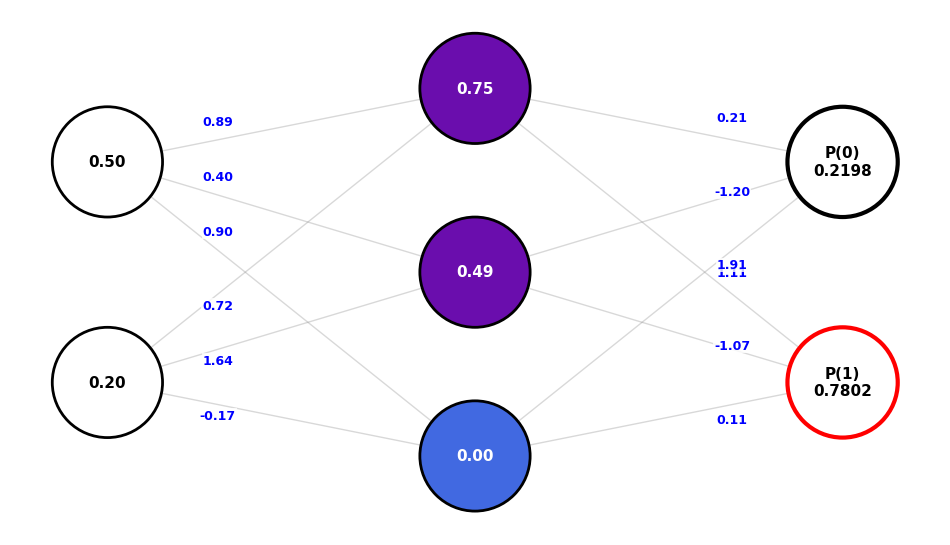

 ITERATION 13 | Loss: 0.2213


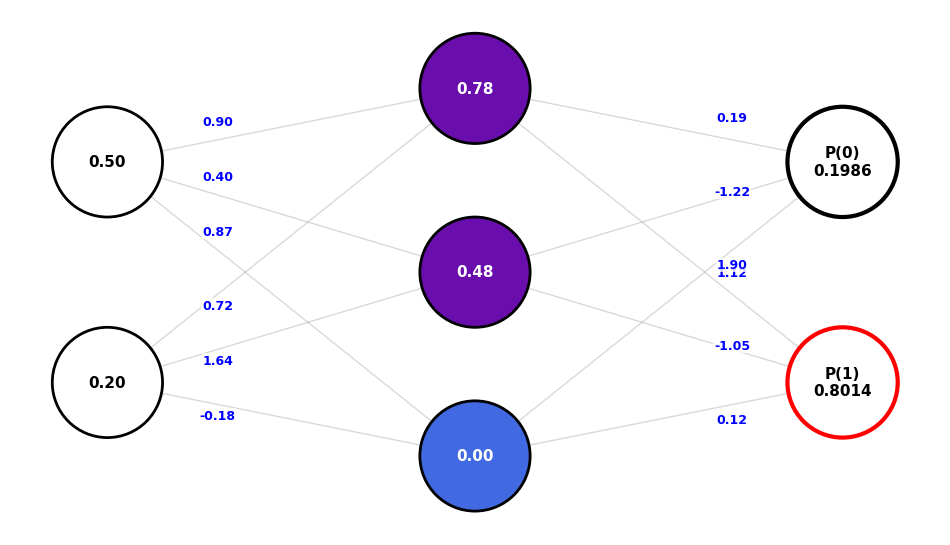

 ITERATION 14 | Loss: 0.1974


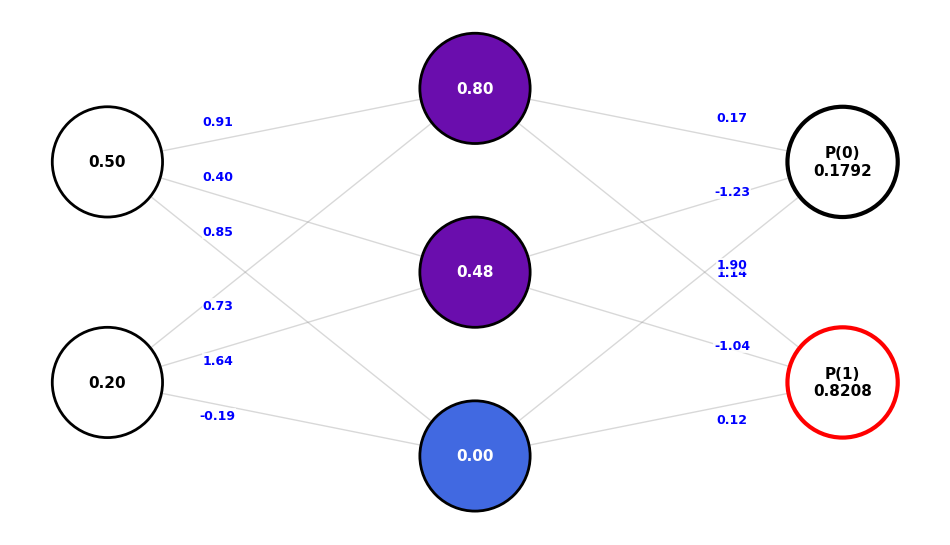

 ITERATION 15 | Loss: 0.1762


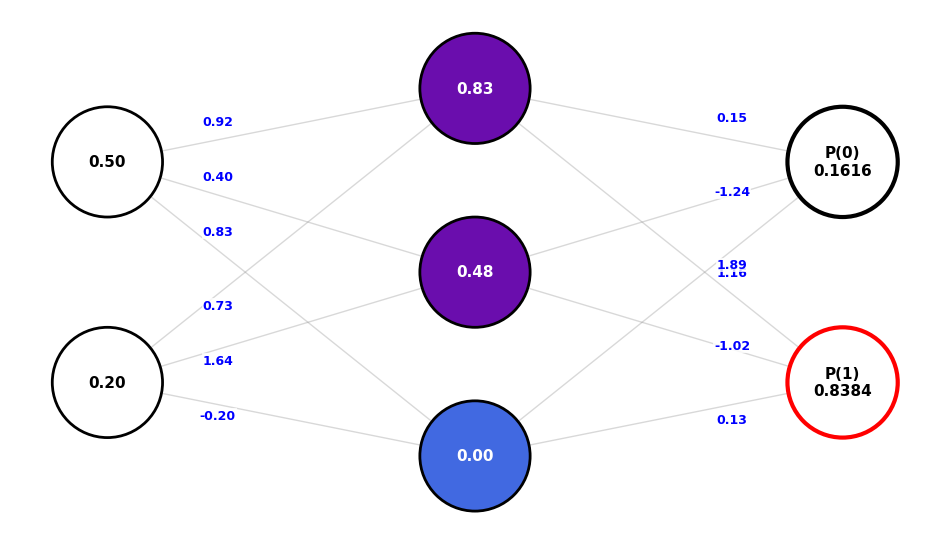

 ITERATION 16 | Loss: 0.1575


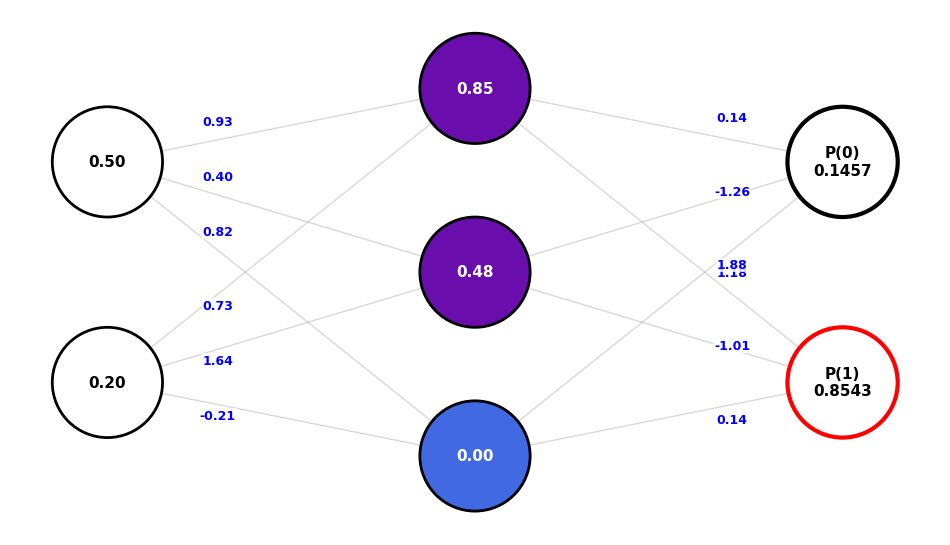

 ITERATION 17 | Loss: 0.1410


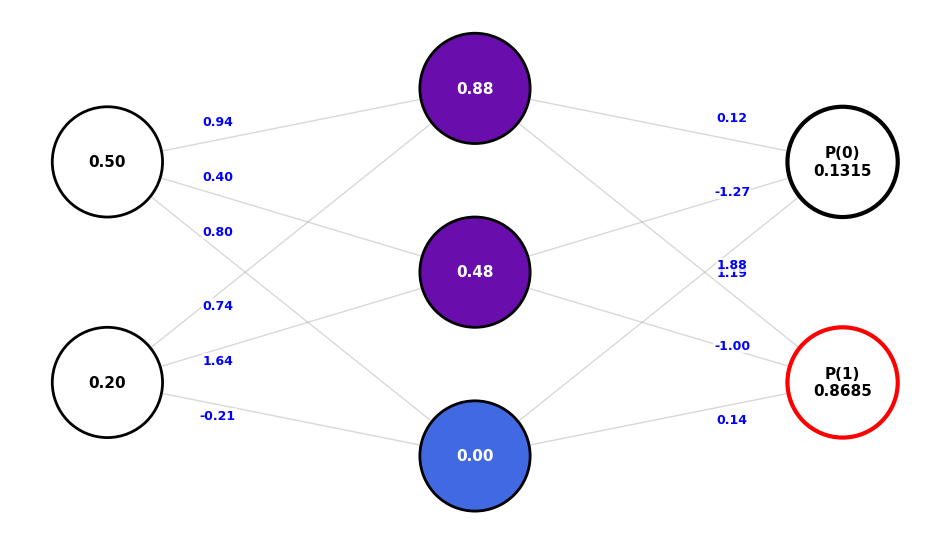

 ITERATION 18 | Loss: 0.1266


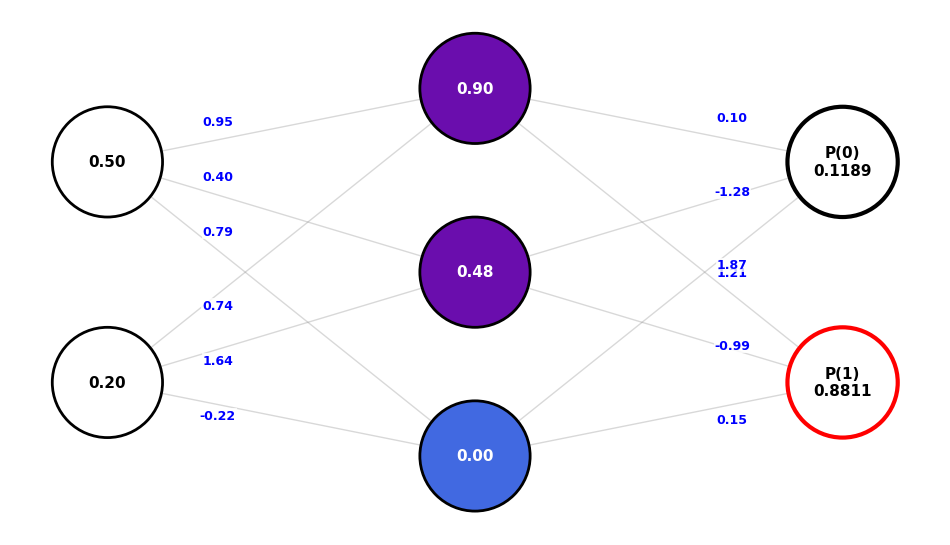

 ITERATION 19 | Loss: 0.1138


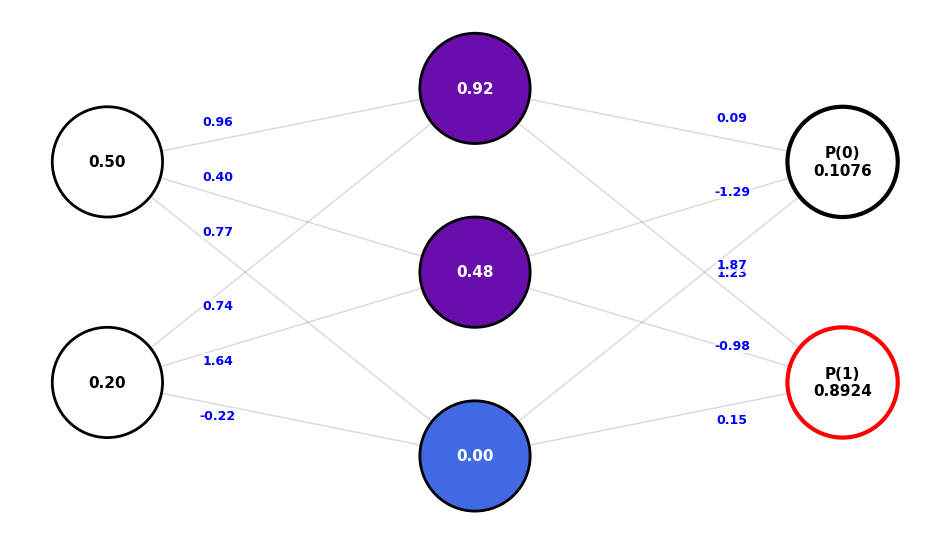

 ITERATION 20 | Loss: 0.1027


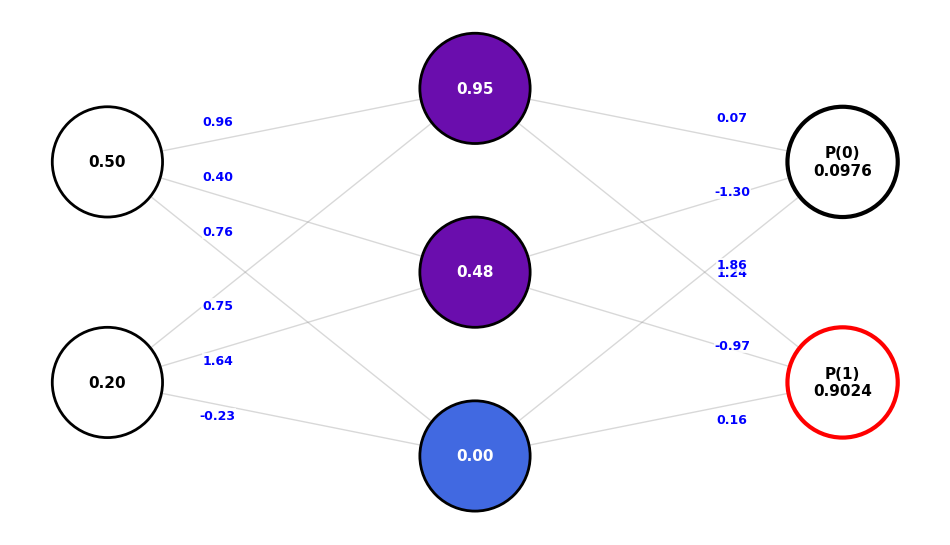

In [84]:
nn = initialize_nn()
x_in = np.array([[0.5], [0.2]])
iterations = 20
learning_rate = 0.1

for i in range(iterations):
    train_step(nn, x_in, y_target, target_idx=1, lr=learning_rate)
    
    print(f"{'='*30}")
    print(f" ITERATION {i+1} | Loss: {nn['loss_history'][-1]:.4f}")
    print(f"{'='*30}")

    draw_network()

<h3>Loss Graph</h3>

The below code cell will output a graph of how the loss changed over the given number of iterations.

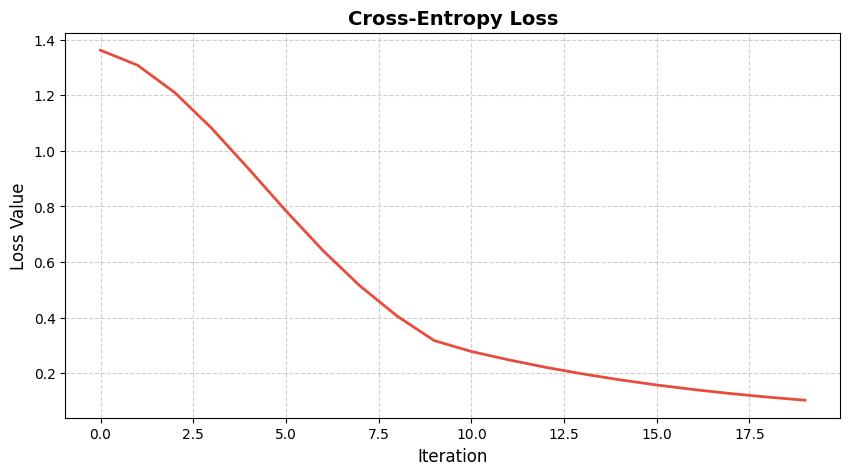

In [87]:
plt.figure(figsize=(10, 5))
plt.plot(nn['loss_history'], color='#e74c3c', lw=2)

plt.title("Cross-Entropy Loss", fontsize=14, fontweight='bold')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Loss Value", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
